In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('delivery_cleaned.csv')

In [3]:
df.shape

(50000, 39)

In [4]:
df[['rating', 'customer_rating', 'delivery_status', 'actual_delivery_hours']].head(10)

,rating,customer_rating,delivery_status,actual_delivery_hours
0,4.52,4.0,delivered,17.15
1,3.65,3.7,delivered,20.12
2,4.28,3.8,delivered,35.20
3,4.66,4.5,delivered,34.32
4,4.49,4.8,delivered,53.06
5,4.44,4.5,delivered,49.99
6,4.30,3.4,delayed,77.36
7,4.19,3.8,delivered,59.36
8,4.76,4.1,delivered,14.40
9,4.64,3.1,delayed,63.88


In [5]:
df[['rating', 'customer_rating']].describe()

,rating,customer_rating
count,50000.000000,50000.000000
mean,4.174164,4.023716
std,0.415679,0.725475
min,3.010000,1.000000
25%,3.880000,3.700000
50%,4.190000,4.100000
75%,4.480000,4.500000
max,5.000000,5.000000


In [6]:
df[['order_date', 'order_time', 'signup_date']].head(10)

,order_date,order_time,signup_date
0,2024-11-25,04:59:28,2025-10-16
1,2024-04-17,15:41:59,2026-02-19
2,2025-11-04,23:49:26,2023-09-10
3,2026-01-12,22:10:34,2024-04-14
4,2026-08-01,00:42:35,2024-11-23
5,2026-05-22,22:18:29,2026-08-09
6,2024-06-05,03:18:19,2025-02-08
7,2026-02-06,10:34:39,2026-05-12
8,2026-04-17,04:57:38,2023-08-30
9,2026-07-22,06:56:43,2024-10-04


In [7]:
df[['order_date', 'order_time']].dtypes

order_date    object
order_time    object
dtype: object

In [8]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [9]:
df['order_date'].dtype

dtype('<M8[ns]')

In [10]:
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S')

In [11]:
df['order_time'].dtype

dtype('<M8[ns]')

In [12]:
df['day_of_week'] = df['order_date'].dt.dayofweek
df['month'] = df['order_date'].dt.month
df['is_weekend'] = (df['order_date'].dt.dayofweek >= 5).astype(int)

In [13]:
df['order_hour'] = df['order_time'].dt.hour

In [14]:
df[['order_date', 'day_of_week', 'month', 'is_weekend',
    'order_time', 'order_hour']].head(10)

,order_date,day_of_week,month,is_weekend,order_time,order_hour
0,2024-11-25,0,11,0,1900-01-01 04:59:28,4
1,2024-04-17,2,4,0,1900-01-01 15:41:59,15
2,2025-11-04,1,11,0,1900-01-01 23:49:26,23
3,2026-01-12,0,1,0,1900-01-01 22:10:34,22
4,2026-08-01,5,8,1,1900-01-01 00:42:35,0
5,2026-05-22,4,5,0,1900-01-01 22:18:29,22
6,2024-06-05,2,6,0,1900-01-01 03:18:19,3
7,2026-02-06,4,2,0,1900-01-01 10:34:39,10
8,2026-04-17,4,4,0,1900-01-01 04:57:38,4
9,2026-07-22,2,7,0,1900-01-01 06:56:43,6


In [15]:
df = df.drop(columns=['order_date', 'order_time', 'signup_date'])

In [16]:
print(df.shape)
print(df.columns.tolist())

(50000, 40)
['order_id', 'customer_id', 'source_city', 'destination_city', 'product_category', 'product_weight_kg', 'order_value', 'distance_km', 'promised_delivery_hours', 'warehouse_id', 'partner_id', 'name', 'age', 'gender', 'city_x', 'customer_type', 'partner_name', 'partner_experience_years', 'vehicle_type', 'rating', 'completed_deliveries', 'partner_city', 'warehouse_name', 'city_y', 'warehouse_type', 'capacity_units', 'staff_count', 'operating_hours', 'event_id', 'pickup_time', 'actual_delivery_hours', 'delivery_status', 'delay_reason', 'delivery_attempts', 'customer_rating', 'late_delivery', 'day_of_week', 'month', 'is_weekend', 'order_hour']


# Feature Creatioon

In [17]:
feature_cols = [
    'source_city',
    'destination_city',
    'product_category',
    'product_weight_kg',
    'order_value',
    'distance_km',
    'promised_delivery_hours',
    'customer_type',
    'partner_experience_years',
    'vehicle_type',
    'rating',
    'completed_deliveries',
    'partner_city',
    'warehouse_type',
    'capacity_units',
    'staff_count',
    'operating_hours',
    'day_of_week',
    'month',
    'is_weekend',
    'order_hour'
]

X = df[feature_cols]
y = df['late_delivery']

In [18]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\ny distribution:")
print(y.value_counts())

X shape: (50000, 21)
y shape: (50000,)

X columns:
['source_city', 'destination_city', 'product_category', 'product_weight_kg', 'order_value', 'distance_km', 'promised_delivery_hours', 'customer_type', 'partner_experience_years', 'vehicle_type', 'rating', 'completed_deliveries', 'partner_city', 'warehouse_type', 'capacity_units', 'staff_count', 'operating_hours', 'day_of_week', 'month', 'is_weekend', 'order_hour']

y distribution:
late_delivery
0    36006
1    13994
Name: count, dtype: int64


In [19]:
X.head()

,source_city,destination_city,product_category,product_weight_kg,order_value,distance_km,promised_delivery_hours,customer_type,partner_experience_years,vehicle_type,...,completed_deliveries,partner_city,warehouse_type,capacity_units,staff_count,operating_hours,day_of_week,month,is_weekend,order_hour
0,bengaluru,delhi,sports,0.90,1437.160,225.62,21.01,regular,1.7,ev,...,2270,bengaluru,distribution center,24080,95,16,0,11,0,4
1,indore,delhi,electronics,0.21,340.440,105.94,22.33,regular,2.8,bike,...,2660,indore,distribution center,31252,96,16,2,4,0,15
2,indore,pune,sports,0.58,1824.555,657.27,36.23,regular,1.4,ev,...,871,indore,sorting hub,50047,192,16,1,11,0,23
3,indore,hyderabad,electronics,0.62,4412.420,797.24,33.97,regular,1.4,bike,...,2168,indore,fulfillment center,77103,173,16,0,1,0,22
4,delhi,mumbai,grocery,1.19,2143.630,844.64,54.02,regular,2.0,van,...,2165,delhi,fulfillment center,60276,211,24,5,8,1,0


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
categorical_cols = [
    'source_city',
    'destination_city',
    'product_category',
    'customer_type',
    'vehicle_type',
    'partner_city',
    'warehouse_type',
    'day_of_week',
    'month'
]

numerical_cols = [
    'product_weight_kg',
    'order_value',
    'distance_km',
    'promised_delivery_hours',
    'partner_experience_years',
    'rating',
    'completed_deliveries',
    'capacity_units',
    'staff_count',
    'operating_hours',
    'is_weekend',
    'order_hour'
]

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [25]:
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [26]:
logistic_model.fit(X_train,y_train)

C:\Users\DELL-7280\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['product_weight_kg',
                                                   'order_value', 'distance_km',
                                                   'promised_delivery_hours',
                                                   'partner_experience_years',
                                                   'rating',
                                                   'completed_deliveries',
                                                   'capacity_units',
                                                   'staff_count',
                                                   'operating_hours',
                                                   'is_weekend',
                                                   'order_hour']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['source_city',
                                                   'destination_city',
                                                   'product_category',
                                                   'customer_type',
                                                   'vehicle_type',
                                                   'partner_city',
                                                   'warehouse_type',
                                                   'day_of_week', 'month'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [27]:
y_pred = logistic_model.predict(X_test)

In [28]:
print(y_pred[:20])
print(y_test.values[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 1 0 1 1 0]


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)

In [30]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print(confusion)

Accuracy : 0.7258
Precision: 0.3902439024390244
Recall   : 0.005854372484449323
F1 Score : 0.011535688536409516
[[7242   25]
 [2717   16]]


In [31]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print(y_prob[:20])

[0.24301525 0.15295338 0.25811204 0.34780218 0.32882436 0.22236392
 0.23824772 0.34602329 0.21550154 0.3011395  0.19875376 0.34664907
 0.3326129  0.1861985  0.25686984 0.27161631 0.36221657 0.47349674
 0.17835112 0.21514355]


In [32]:
print("Minimum probability:", y_prob.min())
print("Maximum probability:", y_prob.max())
print("Mean probability:", y_prob.mean())

Minimum probability: 0.10276474470343223
Maximum probability: 0.6041701111468972
Mean probability: 0.280977559473018


# Decision Tree

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

rf_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ('preprocessor', rf_preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [35]:

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['source_city',
                                                   'destination_city',
                                                   'product_category',
                                                   'customer_type',
                                                   'vehicle_type',
                                                   'partner_city',
                                                   'warehouse_type',
                                                   'day_of_week', 'month']),
                                                 ('num', 'passthrough',
                                                  ['product_weight_kg',
                                                   'order_value', 'distance_km',
                                                   'promised_delivery_hours',
                                                   'partner_experience_years',
                                                   'rating',
                                                   'completed_deliveries',
                                                   'capacity_units',
                                                   'staff_count',
                                                   'operating_hours',
                                                   'is_weekend',
                                                   'order_hour'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [36]:
rf_pred = rf_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.7262
Precision: 0.4827586206896552
Recall   : 0.02561287961946579
F1 Score : 0.048644892286309936


In [37]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print(rf_prob.min())
print(rf_prob.max())
print(rf_prob.mean())

0.055
0.675
0.2921295


In [38]:
print(rf_model.classes_)
print(rf_model.named_steps['model'].classes_)

[0 1]
[0 1]


In [39]:
print(len(rf_model.named_steps['model'].estimators_))

200


In [40]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['source_city',
                                                   'destination_city',
                                                   'product_category',
                                                   'customer_type',
                                                   'vehicle_type',
                                                   'partner_city',
                                                   'warehouse_type',
                                                   'day_of_week', 'month']),
                                                 ('num', 'passthrough',
                                                  ['product_weight_kg',
                                                   'order_value', 'distance_km',
                                                   'promised_delivery_hours',
                                                   'partner_experience_years',
                                                   'rating',
                                                   'completed_deliveries',
                                                   'capacity_units',
                                                   'staff_count',
                                                   'operating_hours',
                                                   'is_weekend',
                                                   'order_hour'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [41]:
print(len(rf_model.named_steps['model'].estimators_))

200


In [42]:
rf_prob = rf_model.predict_proba(X_test)

print(rf_prob.shape)
print(rf_prob[:5])

(10000, 2)
[[0.605 0.395]
 [0.845 0.155]
 [0.635 0.365]
 [0.68  0.32 ]
 [0.69  0.31 ]]


In [43]:
print(len(rf_model.named_steps['model'].estimators_))

200


In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for threshold in [0.5, 0.4, 0.3, 0.2]:
    rf_pred_threshold = (rf_prob[:, 1] >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Accuracy :", accuracy_score(y_test, rf_pred_threshold))
    print("Precision:", precision_score(y_test, rf_pred_threshold))
    print("Recall   :", recall_score(y_test, rf_pred_threshold))
    print("F1 Score :", f1_score(y_test, rf_pred_threshold))


Threshold: 0.5
Accuracy : 0.7257
Precision: 0.46875
Recall   : 0.027442371020856202
F1 Score : 0.05184929139301763

Threshold: 0.4
Accuracy : 0.6876
Precision: 0.37492002559181065
Recall   : 0.21441639224295647
F1 Score : 0.27281191806331473

Threshold: 0.3
Accuracy : 0.5753
Precision: 0.34242298084929224
Recall   : 0.601902671057446
F1 Score : 0.4365132015390739

Threshold: 0.2
Accuracy : 0.4057
Precision: 0.3008684863523573
Recall   : 0.8873033296743505
F1 Score : 0.4493653293801538


In [45]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

for threshold in thresholds:
    pred = (rf_prob[:, 1] >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_test, pred):.3f} | "
        f"Recall: {recall_score(y_test, pred):.3f} | "
        f"F1: {f1_score(y_test, pred):.3f}"
    )

Threshold: 0.10 | Precision: 0.275 | Recall: 0.995 | F1: 0.430
Threshold: 0.15 | Precision: 0.282 | Recall: 0.962 | F1: 0.437
Threshold: 0.20 | Precision: 0.301 | Recall: 0.887 | F1: 0.449
Threshold: 0.25 | Precision: 0.325 | Recall: 0.769 | F1: 0.457
Threshold: 0.30 | Precision: 0.342 | Recall: 0.602 | F1: 0.437
Threshold: 0.35 | Precision: 0.355 | Recall: 0.398 | F1: 0.375
Threshold: 0.40 | Precision: 0.375 | Recall: 0.214 | F1: 0.273
Threshold: 0.45 | Precision: 0.418 | Recall: 0.089 | F1: 0.147
Threshold: 0.50 | Precision: 0.469 | Recall: 0.027 | F1: 0.052


In [46]:
for threshold in [0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28]:
    pred = (rf_prob[:, 1] >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_test, pred):.3f} | "
        f"Recall: {recall_score(y_test, pred):.3f} | "
        f"F1: {f1_score(y_test, pred):.3f}"
    )

Threshold: 0.22 | Precision: 0.310 | Recall: 0.840 | F1: 0.453
Threshold: 0.23 | Precision: 0.314 | Recall: 0.817 | F1: 0.454
Threshold: 0.24 | Precision: 0.320 | Recall: 0.795 | F1: 0.456
Threshold: 0.25 | Precision: 0.325 | Recall: 0.769 | F1: 0.457
Threshold: 0.26 | Precision: 0.330 | Recall: 0.741 | F1: 0.457
Threshold: 0.27 | Precision: 0.333 | Recall: 0.705 | F1: 0.453
Threshold: 0.28 | Precision: 0.340 | Recall: 0.674 | F1: 0.452


In [47]:
final_threshold = 0.25

final_pred = (rf_prob[:, 1] >= final_threshold).astype(int)

In [48]:
print("Accuracy :", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall   :", recall_score(y_test, final_pred))
print("F1 Score :", f1_score(y_test, final_pred))

Accuracy : 0.501
Precision: 0.32528255147855706
Recall   : 0.7687522868642518
F1 Score : 0.4571366405570061


In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_pred)

print(cm)

[[2909 4358]
 [ 632 2101]]


In [50]:
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

print(len(feature_names))
print(feature_names[:20])

80
['cat__source_city_ahmedabad' 'cat__source_city_bengaluru'
 'cat__source_city_chennai' 'cat__source_city_delhi'
 'cat__source_city_hyderabad' 'cat__source_city_indore'
 'cat__source_city_jaipur' 'cat__source_city_kolkata'
 'cat__source_city_mumbai' 'cat__source_city_pune'
 'cat__destination_city_ahmedabad' 'cat__destination_city_bengaluru'
 'cat__destination_city_chennai' 'cat__destination_city_delhi'
 'cat__destination_city_hyderabad' 'cat__destination_city_indore'
 'cat__destination_city_jaipur' 'cat__destination_city_kolkata'
 'cat__destination_city_mumbai' 'cat__destination_city_pune']


In [51]:
importances = rf_model.named_steps['model'].feature_importances_

print(len(importances))

80


In [52]:
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
)

print(importance_df.head(20))

                                  feature  importance
70                       num__distance_km    0.089055
71           num__promised_delivery_hours    0.080187
69                       num__order_value    0.068669
68                 num__product_weight_kg    0.068095
73                            num__rating    0.052963
79                        num__order_hour    0.052216
74              num__completed_deliveries    0.051964
72          num__partner_experience_years    0.047822
75                    num__capacity_units    0.034817
76                       num__staff_count    0.033740
77                   num__operating_hours    0.017407
30             cat__customer_type_regular    0.010273
28                 cat__customer_type_new    0.009173
31                 cat__vehicle_type_bike    0.008841
78                        num__is_weekend    0.008693
51                     cat__day_of_week_2    0.008029
26  cat__product_category_home appliances    0.007850
50                     cat__

In [53]:
# Feature importance ko original feature ke naam par combine karna

importance_df['original_feature'] = (
    importance_df['feature']
    .str.replace('num__', '', regex=False)
    .str.replace(r'cat__[^_]+__', '', regex=True)
)

combined_importance = (
    importance_df
    .groupby('original_feature')['importance']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(combined_importance)

            original_feature  importance
0                distance_km    0.089055
1    promised_delivery_hours    0.080187
2                order_value    0.068669
3          product_weight_kg    0.068095
4                     rating    0.052963
..                       ...         ...
75     cat__source_city_pune    0.003040
76    cat__partner_city_pune    0.002997
77  cat__partner_city_indore    0.002683
78   cat__source_city_indore    0.002665
79   cat__warehouse_type_nan    0.000206

[80 rows x 2 columns]


In [54]:
original_features = numerical_cols + categorical_cols

combined = []

for feature in original_features:
    total_importance = 0

    for name, importance in zip(feature_names, importances):
        if name.startswith(f'num__{feature}') or name.startswith(f'cat__{feature}_'):
            total_importance += importance

    combined.append({
        'feature': feature,
        'importance': total_importance
    })

combined_importance = pd.DataFrame(combined).sort_values(
    'importance',
    ascending=False
)

print(combined_importance.to_string(index=False))

                 feature  importance
             distance_km    0.089055
 promised_delivery_hours    0.080187
                   month    0.077090
             order_value    0.068669
       product_weight_kg    0.068095
        destination_city    0.067286
        product_category    0.061321
             day_of_week    0.053144
                  rating    0.052963
              order_hour    0.052216
    completed_deliveries    0.051964
partner_experience_years    0.047822
          capacity_units    0.034817
             staff_count    0.033740
             source_city    0.032982
            partner_city    0.032855
           customer_type    0.026974
            vehicle_type    0.026349
         operating_hours    0.017407
          warehouse_type    0.016369
              is_weekend    0.008693


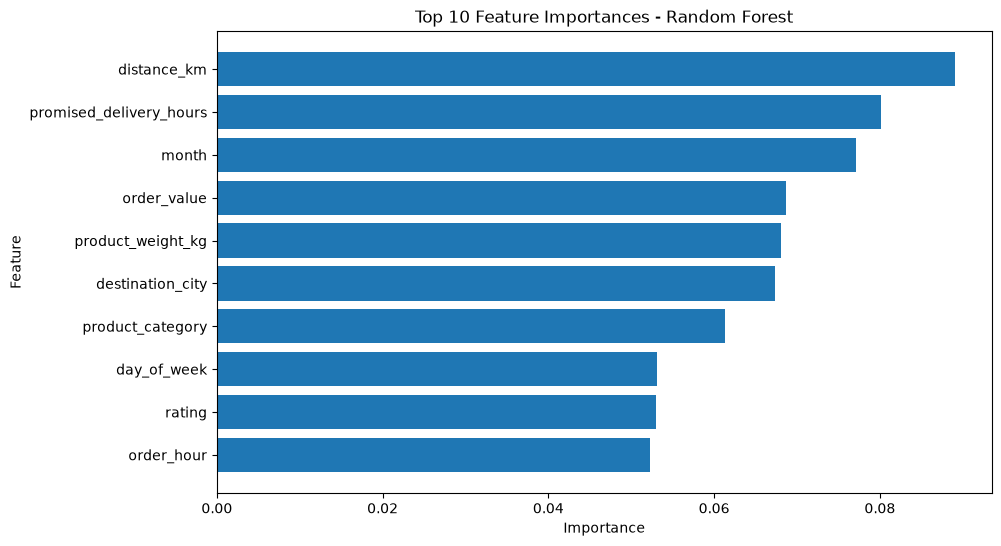

In [55]:
import matplotlib.pyplot as plt

top_features = combined_importance.head(10).sort_values(
    'importance'
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['feature'],
    top_features['importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances - Random Forest')

plt.show()

In [56]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]
    
    print(f"Fold {fold + 1}")
    print("Train:", X_train.shape)
    print("Test :", X_test.shape)

Fold 1
Train: (40000, 21)
Test : (10000, 21)
Fold 2
Train: (40000, 21)
Test : (10000, 21)
Fold 3
Train: (40000, 21)
Test : (10000, 21)
Fold 4
Train: (40000, 21)
Test : (10000, 21)
Fold 5
Train: (40000, 21)
Test : (10000, 21)


In [57]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [58]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [59]:
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=skf,
    scoring='f1'
)

In [60]:
print("F1 Scores:", cv_scores)
print("Mean F1:", cv_scores.mean())
print("Std F1:", cv_scores.std())

F1 Scores: [0.03511777 0.04416136 0.04755839 0.04097311 0.03442341]
Mean F1: 0.04044680751104647
Std F1: 0.005085850821280672


In [61]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    random_state=42
)

In [62]:
gb_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

In [63]:
from sklearn.pipeline import Pipeline

gb_pipeline = Pipeline([
    ('preprocessor', gb_preprocessor),
    ('model', gb_model)
])

In [64]:
gb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['source_city',
                                                   'destination_city',
                                                   'product_category',
                                                   'customer_type',
                                                   'vehicle_type',
                                                   'partner_city',
                                                   'warehouse_type',
                                                   'day_of_week', 'month']),
                                                 ('num', 'passthrough',
                                                  ['product_weight_kg',
                                                   'order_value', 'distance_km',
                                                   'promised_delivery_hours',
                                                   'partner_experience_years',
                                                   'rating',
                                                   'completed_deliveries',
                                                   'capacity_units',
                                                   'staff_count',
                                                   'operating_hours',
                                                   'is_weekend',
                                                   'order_hour'])])),
                ('model',
                 HistGradientBoostingClassifier(max_iter=200,
                                                random_state=42))])

In [65]:
gb_pred = gb_pipeline.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall   :", recall_score(y_test, gb_pred))
print("F1 Score :", f1_score(y_test, gb_pred))

Accuracy : 0.72
Precision: 0.4838709677419355
Recall   : 0.0053590568060021436
F1 Score : 0.01060070671378092


In [67]:
rf_train_prob = rf_model.predict_proba(X_train)[:, 1]

In [68]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_prob = cross_val_predict(
    rf_model,
    X_train,
    y_train,
    cv=skf,
    method='predict_proba'
)[:, 1]

In [69]:
print(oof_prob.shape)
print(oof_prob[:10])

(40000,)
[0.14  0.22  0.295 0.33  0.36  0.355 0.115 0.255 0.32  0.44 ]


In [70]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

for threshold in thresholds:
    oof_pred = (oof_prob >= threshold).astype(int)

    precision = precision_score(y_train, oof_pred)
    recall = recall_score(y_train, oof_pred)
    f1 = f1_score(y_train, oof_pred)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.281 | Recall: 0.995 | F1: 0.439
Threshold: 0.15 | Precision: 0.290 | Recall: 0.962 | F1: 0.446
Threshold: 0.20 | Precision: 0.307 | Recall: 0.890 | F1: 0.456
Threshold: 0.25 | Precision: 0.328 | Recall: 0.777 | F1: 0.462
Threshold: 0.30 | Precision: 0.349 | Recall: 0.602 | F1: 0.442
Threshold: 0.35 | Precision: 0.367 | Recall: 0.383 | F1: 0.375
Threshold: 0.40 | Precision: 0.388 | Recall: 0.189 | F1: 0.254
Threshold: 0.45 | Precision: 0.411 | Recall: 0.075 | F1: 0.127
Threshold: 0.50 | Precision: 0.449 | Recall: 0.024 | F1: 0.045


In [71]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['source_city',
                                                   'destination_city',
                                                   'product_category',
                                                   'customer_type',
                                                   'vehicle_type',
                                                   'partner_city',
                                                   'warehouse_type',
                                                   'day_of_week', 'month']),
                                                 ('num', 'passthrough',
                                                  ['product_weight_kg',
                                                   'order_value', 'distance_km',
                                                   'promised_delivery_hours',
                                                   'partner_experience_years',
                                                   'rating',
                                                   'completed_deliveries',
                                                   'capacity_units',
                                                   'staff_count',
                                                   'operating_hours',
                                                   'is_weekend',
                                                   'order_hour'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [72]:
test_prob = rf_model.predict_proba(X_test)[:, 1]

In [74]:
final_threshold = 0.25

final_pred = (test_prob >= final_threshold).astype(int)

In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall   :", recall_score(y_test, final_pred))
print("F1 Score :", f1_score(y_test, final_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

Accuracy : 0.4999
Precision: 0.3323690621193666
Recall   : 0.7799214005001787
F1 Score : 0.46610440909576173

Confusion Matrix:
[[2816 4385]
 [ 616 2183]]


In [78]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

gb_oof_prob = cross_val_predict(
    gb_pipeline,
    X_train,
    y_train,
    cv=skf,
    method='predict_proba'
)[:, 1]

In [79]:
print(gb_oof_prob.shape)
print(gb_oof_prob[:10])

(40000,)
[0.17382133 0.12231207 0.28529294 0.24342298 0.33676909 0.39838821
 0.1290563  0.16371388 0.34176125 0.34212652]


In [80]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

for threshold in thresholds:
    gb_oof_pred = (gb_oof_prob >= threshold).astype(int)

    precision = precision_score(y_train, gb_oof_pred)
    recall = recall_score(y_train, gb_oof_pred)
    f1 = f1_score(y_train, gb_oof_pred)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.280 | Recall: 1.000 | F1: 0.437
Threshold: 0.15 | Precision: 0.294 | Recall: 0.957 | F1: 0.450
Threshold: 0.20 | Precision: 0.319 | Recall: 0.863 | F1: 0.466
Threshold: 0.25 | Precision: 0.339 | Recall: 0.744 | F1: 0.466
Threshold: 0.30 | Precision: 0.360 | Recall: 0.601 | F1: 0.450
Threshold: 0.35 | Precision: 0.390 | Recall: 0.297 | F1: 0.337
Threshold: 0.40 | Precision: 0.428 | Recall: 0.141 | F1: 0.213
Threshold: 0.45 | Precision: 0.433 | Recall: 0.044 | F1: 0.079
Threshold: 0.50 | Precision: 0.391 | Recall: 0.011 | F1: 0.021


In [81]:
gb_pipeline.fit(X_train, y_train)

gb_test_prob = gb_pipeline.predict_proba(X_test)[:, 1]

gb_final_pred = (gb_test_prob >= 0.20).astype(int)

In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, gb_final_pred))
print("Precision:", precision_score(y_test, gb_final_pred))
print("Recall   :", recall_score(y_test, gb_final_pred))
print("F1 Score :", f1_score(y_test, gb_final_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_final_pred))

Accuracy : 0.4523
Precision: 0.3221307120085016
Recall   : 0.8663808503036798
F1 Score : 0.46964268422581584

Confusion Matrix:
[[2098 5103]
 [ 374 2425]]


In [83]:
max_iter=200
learning_rate=0.1

In [84]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'model__max_iter': [100, 200, 300, 400],
    'model__learning_rate': [0.03, 0.05, 0.08, 0.1, 0.15],
    'model__max_leaf_nodes': [15, 31, 63, 127],
    'model__max_depth': [None, 5, 10, 15]
}

random_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [85]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('cat',
                                                                               OneHotEncoder(handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               ['source_city',
                                                                                'destination_city',
                                                                                'product_category',
                                                                                'customer_type',
                                                                                'vehicle_type',
                                                                                'partner_city',
                                                                                'warehouse_type',
                                                                                'day_of_week',
                                                                                'month']),
                                                                              ('num',
                                                                               'passthrough',
                                                                               ['product_weight_kg',
                                                                                'ord...
                                                                                'operating_hours',
                                                                                'is_weekend',
                                                                                'order_hour'])])),
                                             ('model',
                                              HistGradientBoostingClassifier(max_iter=200,
                                                                             random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.03, 0.05,
                                                                 0.08, 0.1,
                                                                 0.15],
                                        'model__max_depth': [None, 5, 10, 15],
                                        'model__max_iter': [100, 200, 300, 400],
                                        'model__max_leaf_nodes': [15, 31, 63,
                                                                  127]},
                   random_state=42, scoring='f1', verbose=2)

In [86]:
print("Best F1 Score:", random_search.best_score_)
print("Best Parameters:")
print(random_search.best_params_)

Best F1 Score: 0.043463718366213516
Best Parameters:
{'model__max_leaf_nodes': 127, 'model__max_iter': 200, 'model__max_depth': 10, 'model__learning_rate': 0.08}


In [87]:
best_gb_model = random_search.best_estimator_

In [88]:
best_gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['source_city',
                                                   'destination_city',
                                                   'product_category',
                                                   'customer_type',
                                                   'vehicle_type',
                                                   'partner_city',
                                                   'warehouse_type',
                                                   'day_of_week', 'month']),
                                                 ('num', 'passthrough',
                                                  ['product_weight_kg',
                                                   'order_value', 'distance_km',
                                                   'promised_delivery_hours',
                                                   'partner_experience_years',
                                                   'rating',
                                                   'completed_deliveries',
                                                   'capacity_units',
                                                   'staff_count',
                                                   'operating_hours',
                                                   'is_weekend',
                                                   'order_hour'])])),
                ('model',
                 HistGradientBoostingClassifier(learning_rate=0.08,
                                                max_depth=10, max_iter=200,
                                                max_leaf_nodes=127,
                                                random_state=42))])

In [89]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

tuned_oof_prob = cross_val_predict(
    best_gb_model,
    X_train,
    y_train,
    cv=skf,
    method='predict_proba'
)[:, 1]

print(tuned_oof_prob.shape)

(40000,)


In [90]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

for threshold in thresholds:
    pred = (tuned_oof_prob >= threshold).astype(int)

    precision = precision_score(y_train, pred)
    recall = recall_score(y_train, pred)
    f1 = f1_score(y_train, pred)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.280 | Recall: 0.998 | F1: 0.438
Threshold: 0.15 | Precision: 0.294 | Recall: 0.950 | F1: 0.449
Threshold: 0.20 | Precision: 0.318 | Recall: 0.851 | F1: 0.463
Threshold: 0.25 | Precision: 0.338 | Recall: 0.732 | F1: 0.462
Threshold: 0.30 | Precision: 0.356 | Recall: 0.580 | F1: 0.442
Threshold: 0.35 | Precision: 0.377 | Recall: 0.306 | F1: 0.338
Threshold: 0.40 | Precision: 0.396 | Recall: 0.139 | F1: 0.206
Threshold: 0.45 | Precision: 0.419 | Recall: 0.059 | F1: 0.103
Threshold: 0.50 | Precision: 0.433 | Recall: 0.022 | F1: 0.041


In [91]:
best_gb_model.fit(X_train, y_train)

tuned_test_prob = best_gb_model.predict_proba(X_test)[:, 1]

final_threshold = 0.20

tuned_final_pred = (
    tuned_test_prob >= final_threshold
).astype(int)

In [92]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, tuned_final_pred))
print("Precision:", precision_score(y_test, tuned_final_pred))
print("Recall   :", recall_score(y_test, tuned_final_pred))
print("F1 Score :", f1_score(y_test, tuned_final_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_final_pred))

Accuracy : 0.4526
Precision: 0.32202262142381904
Recall   : 0.8645944980350125
F1 Score : 0.4692650765949195

Confusion Matrix:
[[2106 5095]
 [ 379 2420]]


In [93]:
import joblib
import os

# Models folder create karo agar nahi hai
os.makedirs("../Model", exist_ok=True)

# Final model train - fit tuned/best pipeline cleanly
best_gb_model.fit(X_train, y_train)

# Model save
joblib.dump(best_gb_model, "../Model/delivery_gb_model.pkl")

print("Final model saved successfully!")


Final model saved successfully!


In [95]:
final_threshold = 0.20

joblib.dump(
    final_threshold,
    "../Model/delivery_threshold.pkl"
)

print("Threshold saved:", final_threshold)

Threshold saved: 0.2
